In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(
    "cleaned_customer_support_tickets.csv"
)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [5]:
df.shape

(8469, 17)

In [6]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [8]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [13]:
df['Date of Purchase'] = pd.to_datetime(
    df['Date of Purchase']
)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   str           
 2   Customer Email                8469 non-null   str           
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   str           
 5   Product Purchased             8469 non-null   str           
 6   Date of Purchase              8469 non-null   datetime64[us]
 7   Ticket Type                   8469 non-null   str           
 8   Ticket Subject                8469 non-null   str           
 9   Ticket Description            8469 non-null   str           
 10  Ticket Status                 8469 non-null   str           
 11  Resolution                    2769 non-nu

In [15]:
df['month'] = df[
    'Date of Purchase'
].dt.month_name()

In [16]:
df['day_name'] = df[
    'Date of Purchase'
].dt.day_name()

In [17]:
df['year'] = df[
    'Date of Purchase'
].dt.year

In [18]:
df[['Date of Purchase',
    'month',
    'day_name',
    'year']].head()

,Date of Purchase,month,day_name,year
0,2021-03-22,March,Monday,2021
1,2021-05-22,May,Saturday,2021
2,2020-07-14,July,Tuesday,2020
3,2020-11-13,November,Friday,2020
4,2020-02-04,February,Tuesday,2020


In [19]:
df['Ticket Priority'].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [20]:
df['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [21]:
df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [22]:
df['Customer Gender'].value_counts()

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

In [23]:
df.groupby(
    'Ticket Priority'
)[
    'Customer Satisfaction Rating'
].mean()

Ticket Priority
Critical    2.958678
High        2.982979
Low         3.052795
Medium      2.976945
Name: Customer Satisfaction Rating, dtype: float64

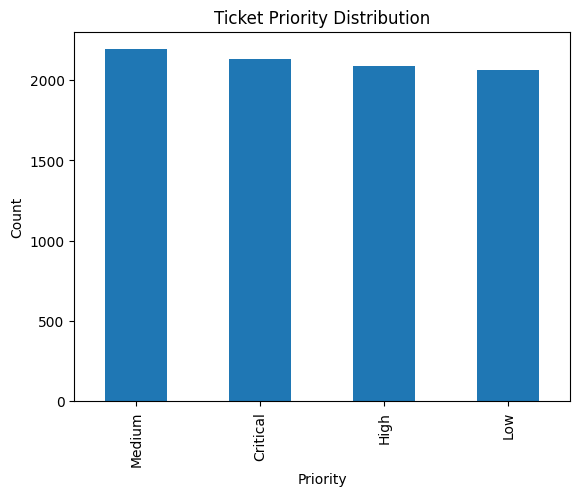

In [24]:
df['Ticket Priority'].value_counts().plot(
    kind='bar'
)

plt.title(
    "Ticket Priority Distribution"
)

plt.xlabel("Priority")

plt.ylabel("Count")

plt.show()

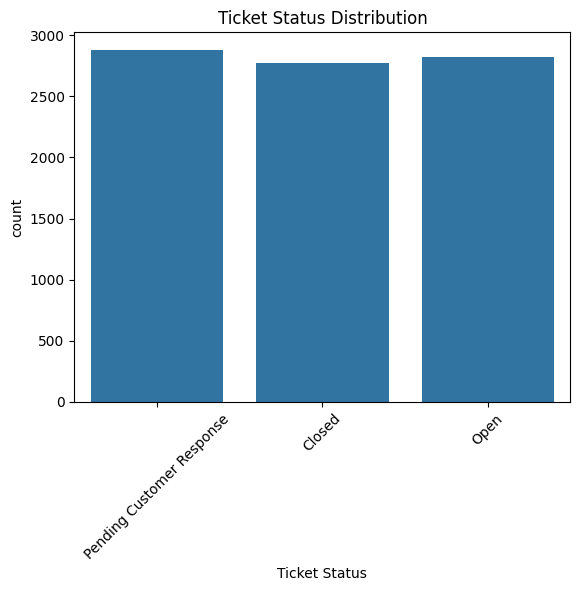

In [25]:
sns.countplot(
    x='Ticket Status',
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Ticket Status Distribution"
)

plt.show()

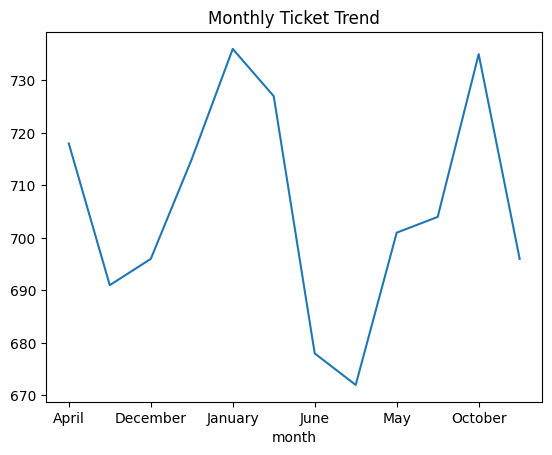

In [26]:
monthly = df.groupby(
    'month'
).size()

monthly.plot()

plt.title(
    "Monthly Ticket Trend"
)

plt.show()

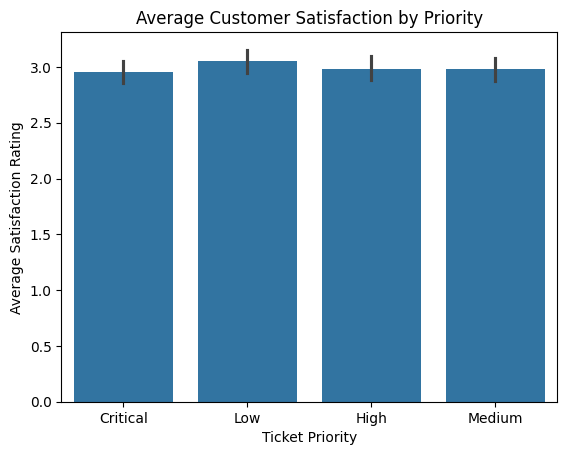

In [31]:
sns.barplot(
    x='Ticket Priority',
    y='Customer Satisfaction Rating',
    data=df
)

plt.title(
    "Average Customer Satisfaction by Priority"
)

plt.xlabel("Ticket Priority")

plt.ylabel("Average Satisfaction Rating")

plt.show()